In [37]:
from pathlib import Path
import sys

import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

project_root = Path("/Users/aakarbyshev/Documents/University/VKR/code/Calibration_WGAN-tests")
sys.path.insert(0, str(project_root))

from scripts.utils import AgingFactorGenerator, aggregate_cell_stats, get_cellid_counts_per_event
from scripts.plot_graphics import PlotGenerator

sns.set_theme(style="whitegrid")

In [38]:
with open("/Users/aakarbyshev/Documents/University/VKR/code/Calibration_WGAN-tests/configs/config.yaml") as f:
    config = yaml.safe_load(f)
df = pd.read_csv(config["data_path"])
aging_cfg = config.get("aging", {})
results_dir = Path(config["results_dir"])
results_dir.mkdir(exist_ok=True)

In [39]:
generator = AgingFactorGenerator(
    aging_function=aging_cfg.get("function", "xyz"),
    af_min=aging_cfg.get("af_min", 0.8),
    af_max=aging_cfg.get("af_max", 1.0),
    sigma=aging_cfg.get("sigma", 0.0),
    noise_seed=aging_cfg.get("noise_seed"),
    event_col=aging_cfg.get("event_col", "event"),
    x_col=aging_cfg.get("x_col", "x"),
    y_col=aging_cfg.get("y_col", "y"),
    z_col=aging_cfg.get("z_col", "z"),
    energy_col=aging_cfg.get("energy_col", "E"),
)
aged = generator.generate(df)
subset = generator.sample_events(aged, n_events=aging_cfg.get("n_events"), seed=aging_cfg.get("noise_seed"))
dataset = subset[[generator.event_col, "cell_key", generator.x_col, generator.y_col, generator.z_col, "E_new", "E_old", "aging_factor"]]
dataset

,event,cell_key,x,y,z,E_new,E_old,aging_factor
0,0,"(7.5, -25.5, -136.4915)",7.5,-25.5,-136.4915,682.457989,571.407704,0.837279
1,0,"(-4.5, -16.5, -131.4905)",-4.5,-16.5,-131.4905,219.605838,NaN,0.816433
2,0,"(-4.5, -13.5, -131.4905)",-4.5,-13.5,-131.4905,1274.081248,1033.467502,0.811147
3,0,"(-1.5, -16.5, -131.4905)",-1.5,-16.5,-131.4905,447.282884,364.717012,0.815406
4,0,"(-1.5, -16.5, -126.4895)",-1.5,-16.5,-126.4895,627.502513,511.926561,0.815816
...,...,...,...,...,...,...,...,...
1185644,99999,"(4.5, -1.5, -96.48350000000002)",4.5,-1.5,-96.4835,1085.950017,870.094599,0.801229
1185645,99999,"(7.5, -1.5, -96.48350000000002)",7.5,-1.5,-96.4835,336.263208,270.452287,0.804287
1185646,99999,"(1.5, 4.5, -91.48250000000002)",1.5,4.5,-91.4825,754.862836,605.127649,0.801639
1185647,99999,"(4.5, 7.5, -91.48250000000002)",4.5,7.5,-91.4825,636.009632,512.666880,0.806068


In [40]:
dataset.cell_key.idxmax()

261020

### Распределения `E_new` и `E_old`


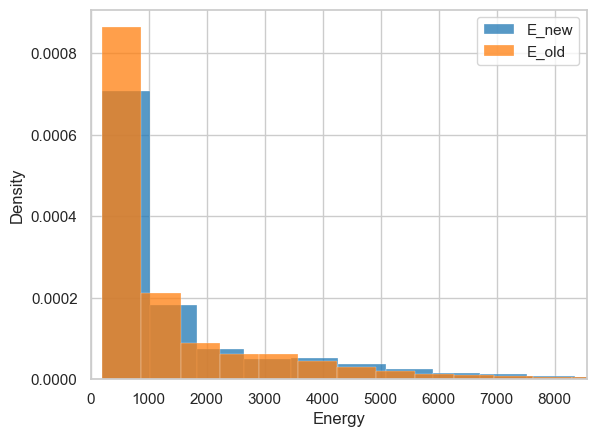

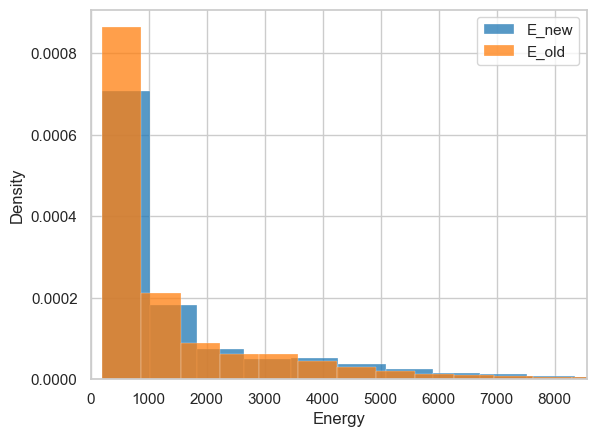

In [41]:
plotter = PlotGenerator(config)
plotter.plot(dataset, "energy_distribution", config)
#конфигурировать плотность или абсолюты

In [42]:
cell_stats = aggregate_cell_stats(dataset)
cell_stats.head()

,freq,x,y,z,aging,mean_E_new,mean_E_old,shift,ratio
cell_key,,,,,,,,,
"(-70.5, -70.5, -146.49349999999998)",1,-70.5,-70.5,-146.4935,0.994462,424.071370,421.722667,-2.348703,0.994462
"(-70.5, -70.5, -126.4895)",2,-70.5,-70.5,-126.4895,0.996103,1181.453300,1176.848662,-4.604639,0.996103
"(-70.5, -70.5, -101.4845)",1,-70.5,-70.5,-101.4845,0.998154,229.309585,228.886244,-0.423341,0.998154
"(-70.5, -70.5, -91.48250000000002)",1,-70.5,-70.5,-91.4825,0.998974,377.466604,377.079459,-0.387145,0.998974
"(-70.5, -70.5, -71.47850000000003)",1,-70.5,-70.5,-71.4785,1.000000,249.976839,249.976839,0.000000,1.000000


In [43]:
cell_stats["shift"].mean()

-155.58987208849132

### Зависимость aging-фактора от частоты ячейки

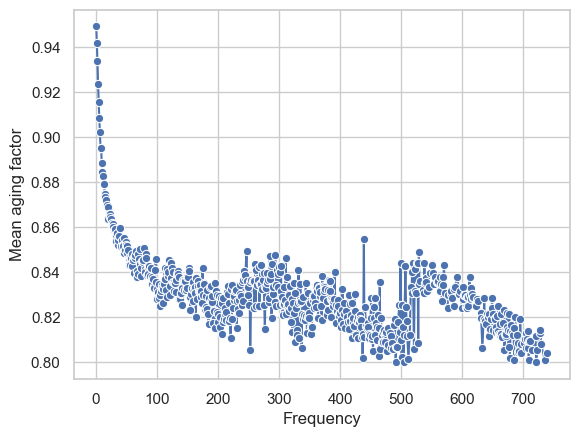

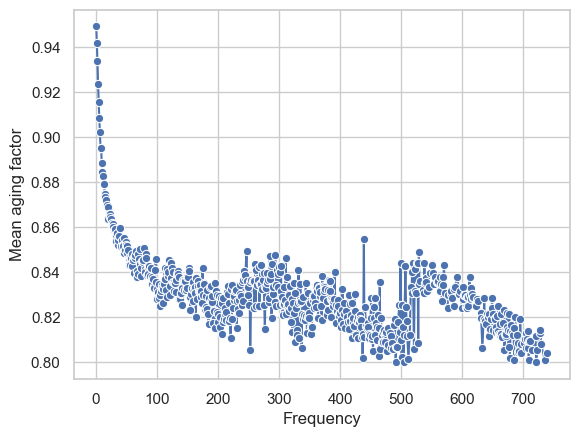

In [44]:
plotter.plot_aging_vs_frequency(cell_stats, "aging_vs_frequency", config)

### Корреляции aging-фактора и координат



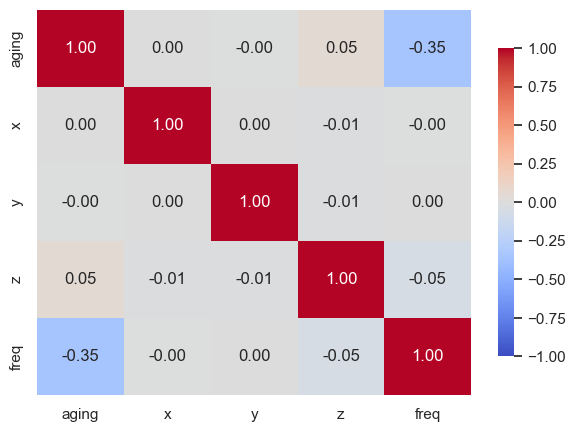

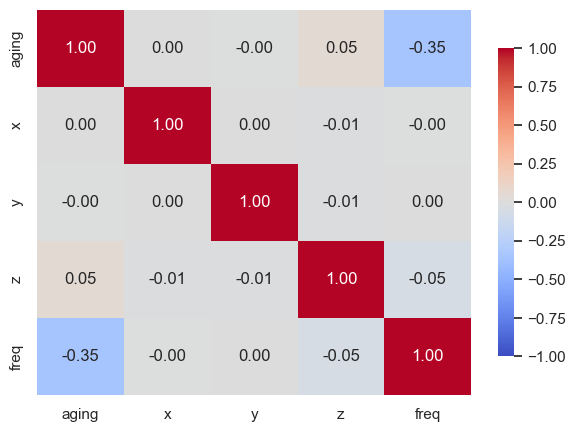

In [45]:
plotter.plot_aging_correlations(cell_stats, "aging_correlations", config)

### Средний aging-эффект по слоям z

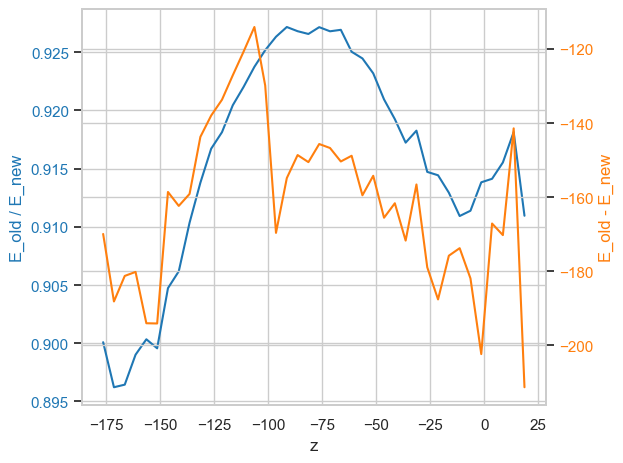

In [46]:
z_profile = cell_stats.groupby("z").agg(mean_ratio=("ratio", "mean"), mean_shift=("shift", "mean"))
fig, ax1 = plt.subplots()
color_ratio = "#1f77b4"
color_shift = "#ff7f0e"
ax1.plot(z_profile.index, z_profile["mean_ratio"], color=color_ratio, label="mean ratio")
ax1.set_xlabel("z")
ax1.set_ylabel("E_old / E_new", color=color_ratio)
ax1.tick_params(axis="y", labelcolor=color_ratio)
ax2 = ax1.twinx()
ax2.plot(z_profile.index, z_profile["mean_shift"], color=color_shift, label="mean shift")
ax2.set_ylabel("E_old - E_new", color=color_shift)
ax2.tick_params(axis="y", labelcolor=color_shift)
fig.savefig(results_dir / "aging_effect_z_profile.png", dpi=150, bbox_inches="tight")
fig.tight_layout()
plt.show()


### Распределение `E_old - E_new`


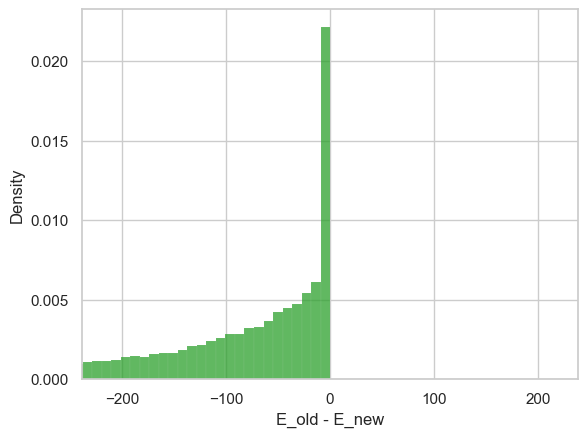

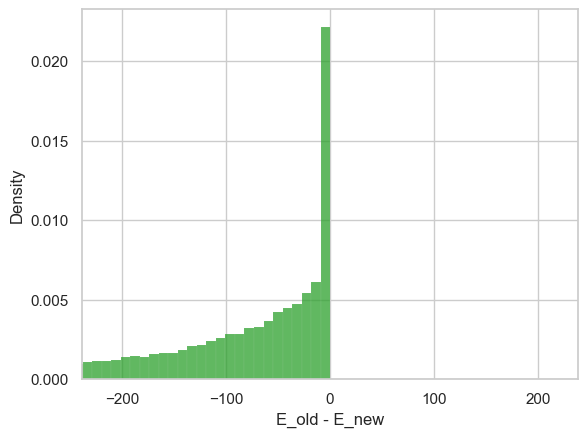

In [47]:
plotter.plot_global_shift_hist(cell_stats, "global_shift_hist", config)

### Глобальный сдвиг энергии

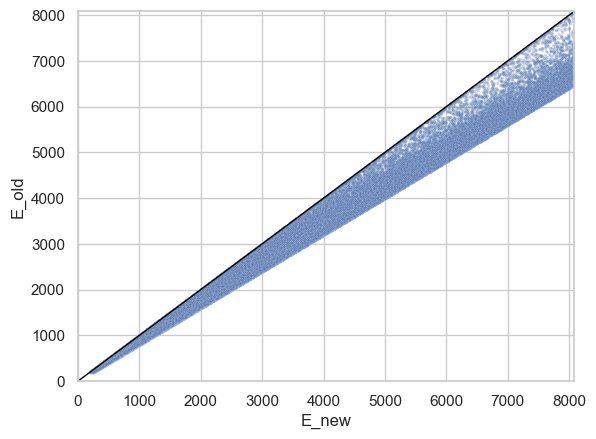

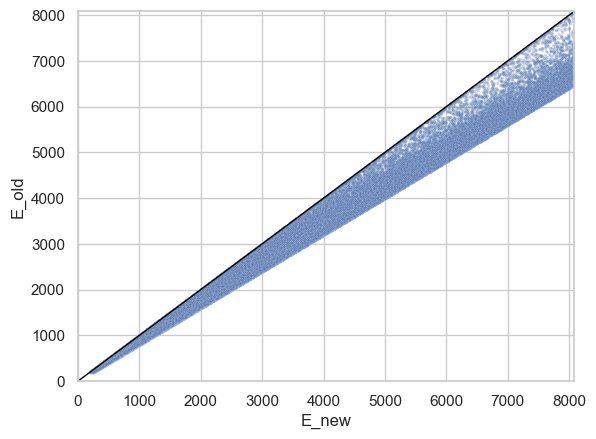

In [48]:
plotter.plot_global_energy_shift(dataset, "global_energy_shift", config)

### Распределения энергии для выбранной ячейки

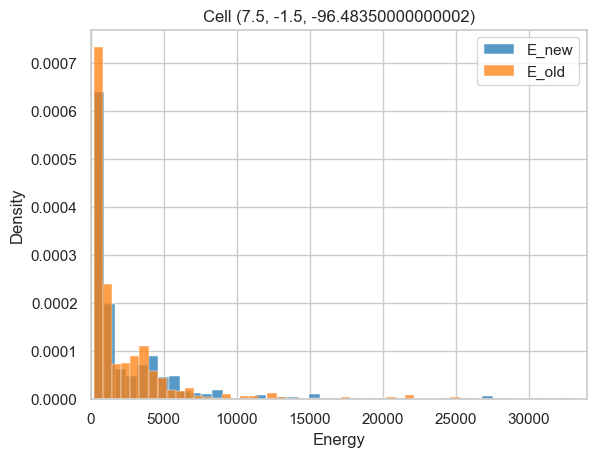

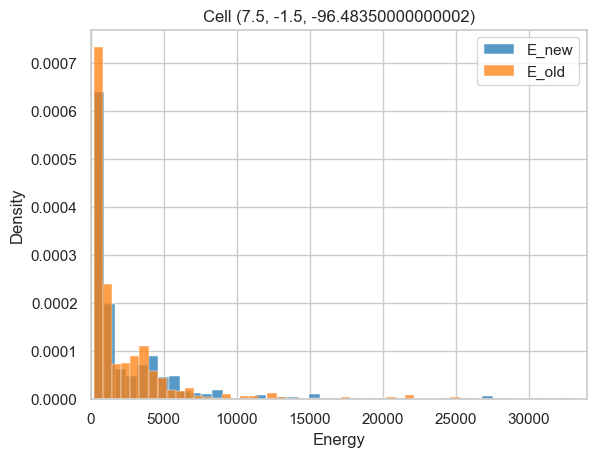

In [49]:
plotter.plot_energy_distribution_cell(dataset, cell_stats, "energy_distribution_cell", config)

### Эффект aging-фактора по координатам

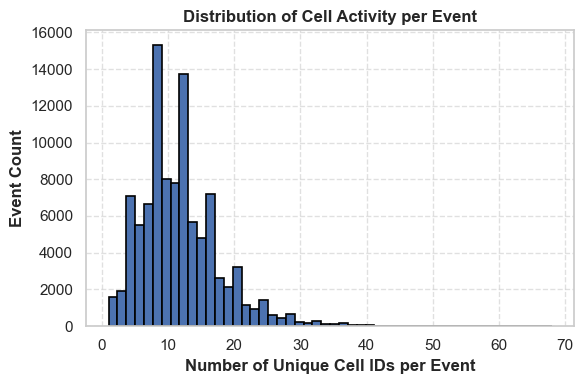

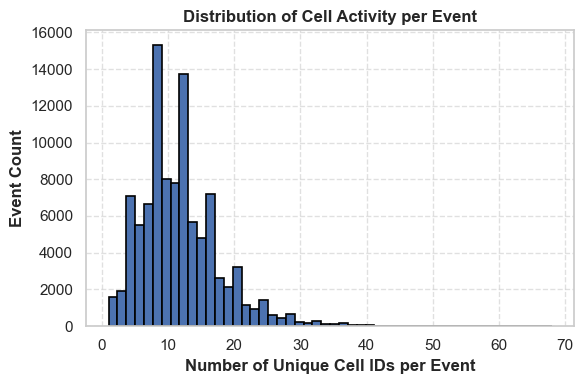

In [50]:
cellid_counts_per_event = get_cellid_counts_per_event(dataset)
plotter.plot_cell_activity_distribution(cellid_counts_per_event, "cell_activity_distribution", config)

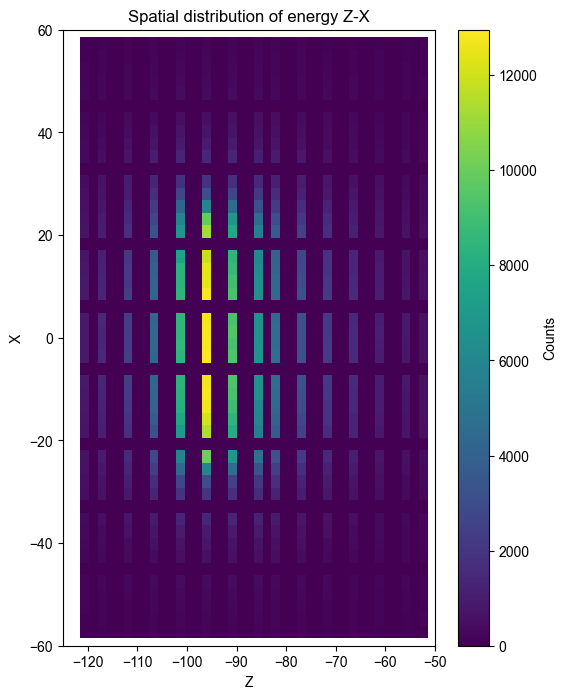

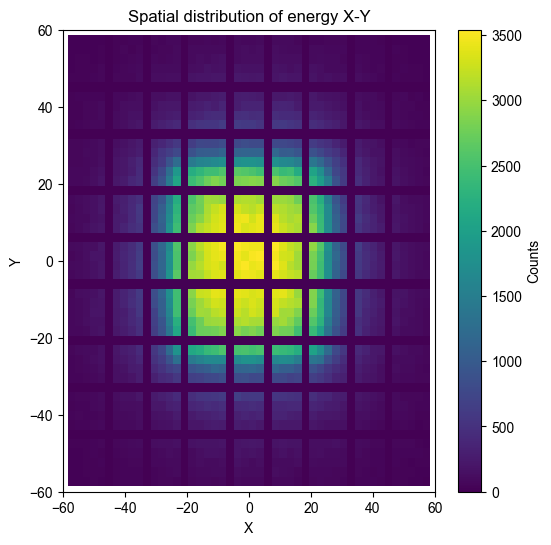

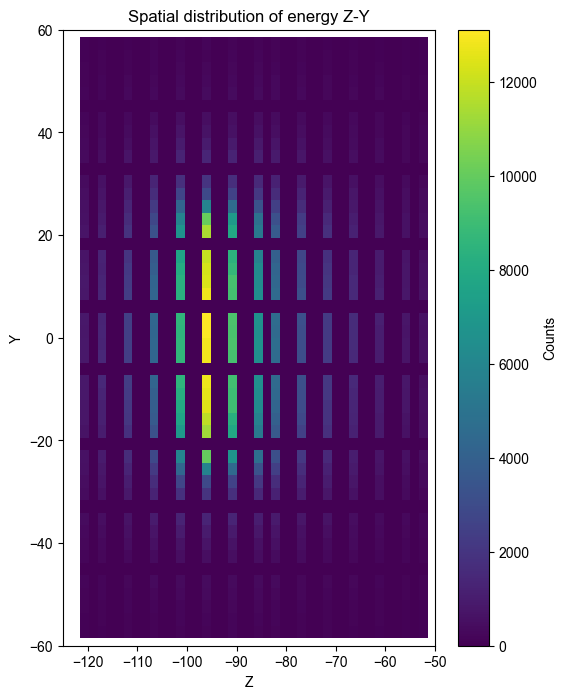

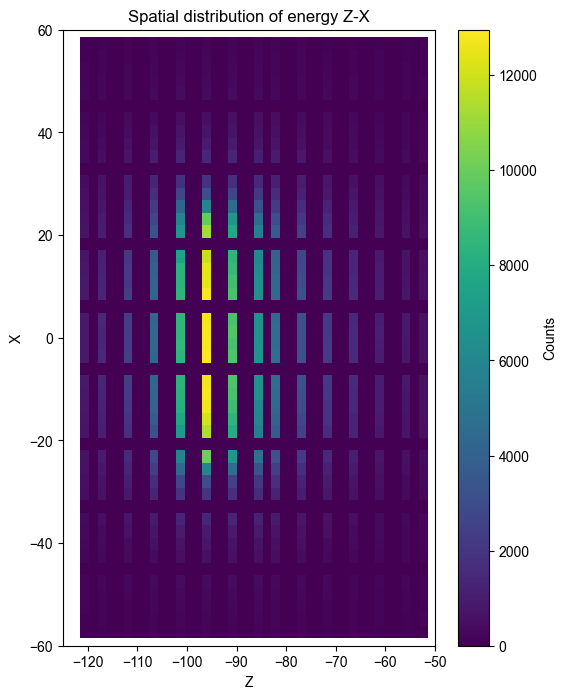

In [51]:
plotter.plot_spatial_distribution(df, "xy", "spatial_distribution_xy.png", config)
plotter.plot_spatial_distribution(df, "zy", "spatial_distribution_zy.png", config)
plotter.plot_spatial_distribution(df, "zx", "spatial_distribution_zx.png", config)


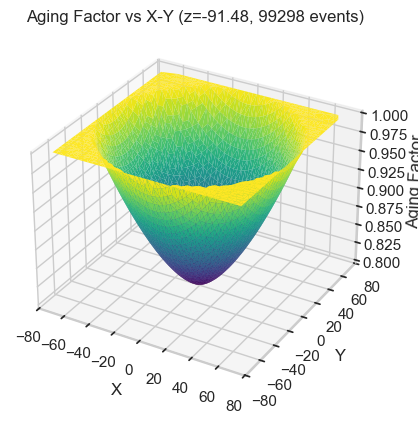

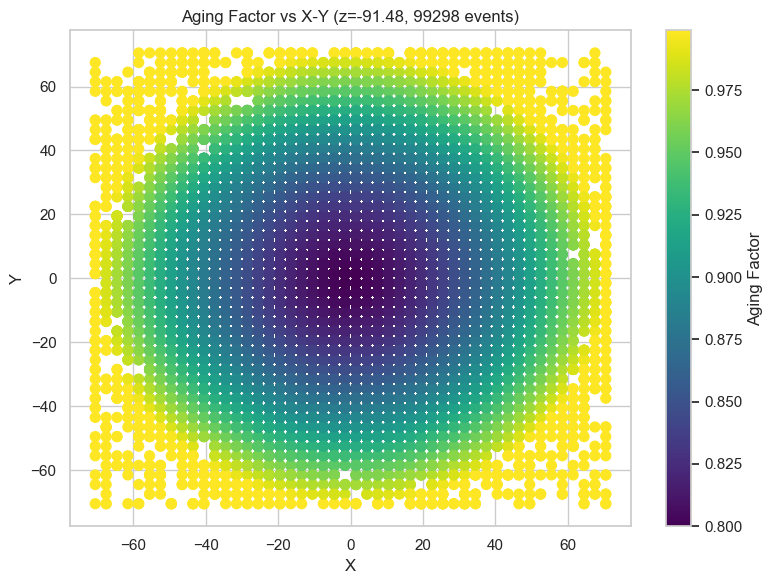

In [52]:
plotter.plot_aging_factor_xy(dataset, "aging_factor_xy", config)
plt.show()


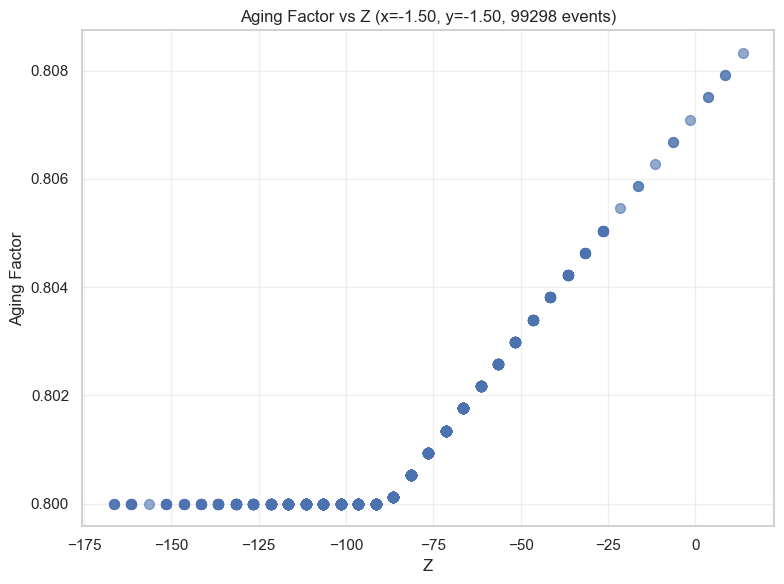

In [53]:
plotter.plot_aging_factor_z(dataset, "aging_factor_z", config)
plt.show()


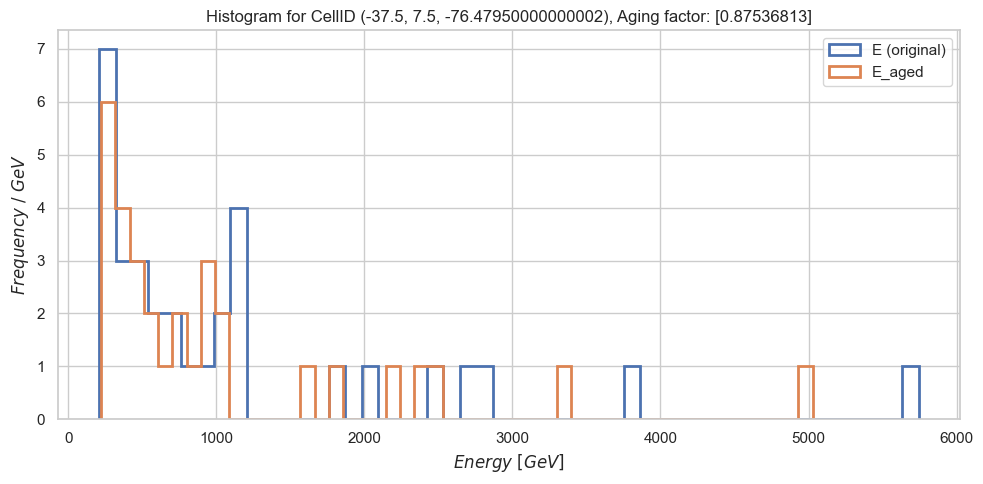

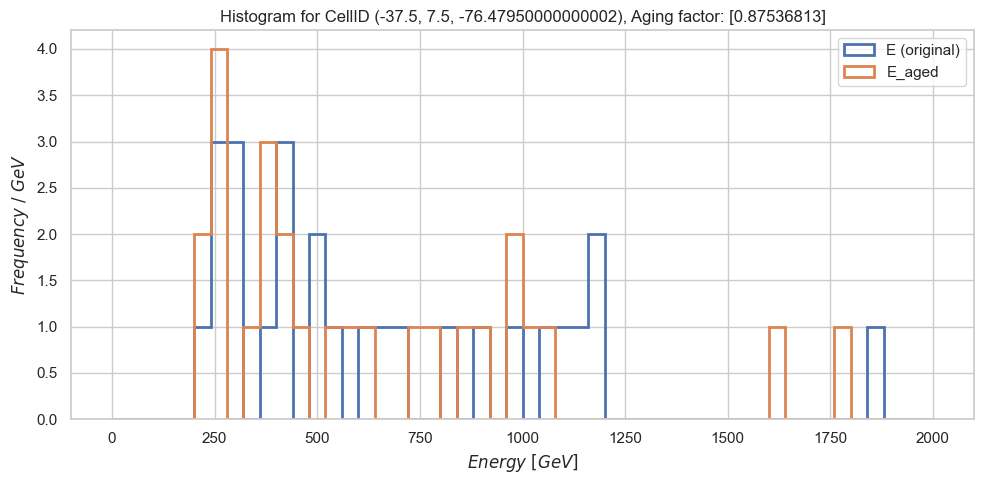

In [57]:
plotter.plot_energy_histogram_cell(dataset, cell_stats, "energy_histogram_cell", config)
plt.show()
